In [3]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [4]:
# Experiment settings

shots = 1024
n_values = [1, 3, 5]
theta_values = np.radians(np.arange(0, 181, 10))

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

label_map = {
    "no_error": "No Error",
    "E1_before_H": r"$\mathcal{E}_1$ before first $H$",
    "E2_after_first_H": r"$\mathcal{E}_2$ after first $H$",
    "E3_after_oracle": r"$\mathcal{E}_3$ after oracle",
    "E4_after_final_H": r"$\mathcal{E}_4$ after final $H$",
}

In [5]:
# Run simulation with shots


results = []
for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        # Original DJA without error
        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)
        samples_ref = qa.deutsch_jozsa.sample_measurements_input(
            state_ref, n, shots
        )

        P0_ref = samples_ref[0] / shots

        for theta in theta_values:
            for axis_name, axis in axes.items():

                results.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": np.degrees(theta),
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": "no_error",
                    "P0": P0_ref,
                    "shots": shots,
                })

                # E1, E2, E3, E4
                for error_name, error_function in error_positions.items():

                    state_error = error_function(
                        n, f, theta, target_qubit, axis
                    )

                    samples_error = qa.deutsch_jozsa.sample_measurements_input(
                        state_error, n, shots
                    )

                    P0_error = samples_error[0] / shots

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": np.degrees(theta),
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": error_name,
                        "P0": P0_error,
                        "shots": shots,
                    })

df = pd.DataFrame(results)

df.head()

Running n = 1
Running n = 3
Running n = 5


,n,theta_rad,theta_deg,axis,target_qubit,function,error_position,P0,shots
0,1,0.0,0.0,X,0,constant_1,no_error,1.0,1024
1,1,0.0,0.0,X,0,constant_1,E1_before_H,1.0,1024
2,1,0.0,0.0,X,0,constant_1,E2_after_first_H,1.0,1024
3,1,0.0,0.0,X,0,constant_1,E3_after_oracle,1.0,1024
4,1,0.0,0.0,X,0,constant_1,E4_after_final_H,1.0,1024


In [6]:
def function_to_latex(function_plot):
    if function_plot == "constant_0":
        return r"\mathrm{constant}_0"
    elif function_plot == "constant_1":
        return r"\mathrm{constant}_1"
    elif function_plot == "balanced":
        return r"\mathrm{balanced}"
    else:
        return rf"\mathrm{{{function_plot}}}"


def error_label(error_pos, axis):
    if error_pos == "no_error":
        return "Ideal circuit"

    position_map = {
        "E1_before_H": "E_1",
        "E2_after_first_H": "E_2",
        "E3_after_oracle": "E_3",
        "E4_after_final_H": "E_4",
    }

    return rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at ${position_map[error_pos]}$"


def add_ideal_reference(df):
    ideal = df[df["error_position"] == "no_error"][
        ["n", "theta_deg", "axis", "function", "P0"]
    ].rename(columns={"P0": "P0_ideal"})

    return df.merge(
        ideal,
        on=["n", "theta_deg", "axis", "function"],
        how="left"
    )


def plot_error_positions(df, n_plot, axis_plot, function_plot, shots=1024):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["axis"] == axis_plot) &
        (df["function"] == function_plot)
    ]

    plt.figure(figsize=(8, 5), dpi=150)

    axis = axis_plot.upper()

    labels = {
        "no_error": "Ideal circuit",
        "E1_before_H": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_1$",
        "E2_after_first_H": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_2$",
        "E3_after_oracle": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_3$",
        "E4_after_final_H": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_4$",
    }

    for error_pos, label in labels.items():
        subset = plot_df[plot_df["error_position"] == error_pos]

        if subset.empty:
            continue

        plt.plot(
            subset["theta_deg"],
            subset["P0"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=label
        )

    function_label = function_to_latex(function_plot)

    plt.xlabel(r"Rotation angle $\theta$ (degrees)", fontsize=12)
    plt.ylabel(r"Probability $P(0\ldots0)$", fontsize=12)

    plt.title(
        rf"{axis_plot}-axis rotation error in the Deutsch--Jozsa algorithm"
        "\n"
        rf"$f(x)={function_label},\; n={n_plot},\; \mathrm{{shots}}={shots}$",
        fontsize=13,
    )

    plt.ylim(-0.1, 1.05)
    plt.xlim(0, 180)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_sensitivity(df, n_plot, axis_plot, function_plot, shots=1024):

    df2 = add_ideal_reference(df)

    plot_df = df2[
        (df2["n"] == n_plot) &
        (df2["axis"] == axis_plot) &
        (df2["function"] == function_plot) &
        (df2["error_position"] != "no_error")
    ].copy()

    plot_df["delta_P"] = np.abs(plot_df["P0"] - plot_df["P0_ideal"])

    plt.figure(figsize=(8, 5), dpi=150)

    axis = axis_plot.upper()

    for error_pos in [
        "E1_before_H",
        "E2_after_first_H",
        "E3_after_oracle",
        "E4_after_final_H",
    ]:
        subset = plot_df[plot_df["error_position"] == error_pos]

        if subset.empty:
            continue

        plt.plot(
            subset["theta_deg"],
            subset["delta_P"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=error_label(error_pos, axis)
        )

    function_label = function_to_latex(function_plot)

    plt.xlabel(r"Rotation angle $\theta$ (degrees)", fontsize=12)
    plt.ylabel(r"Sensitivity $|P_{\mathrm{error}} - P_{\mathrm{ideal}}|$", fontsize=12)

    plt.title(
        rf"Sensitivity to $R_{{{axis}}}(\theta)$ errors"
        "\n"
        rf"$f(x)={function_label},\; n={n_plot},\; \mathrm{{shots}}={shots}$",
        fontsize=13,
    )

    plt.xlim(0, 180)
    plt.ylim(-0.05, 1.05)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()





def plot_axis_comparison(df, n_plot, function_plot, error_position, shots=1024):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["function"] == function_plot) &
        (df["error_position"] == error_position)
    ]

    plt.figure(figsize=(8, 5), dpi=150)

    for axis_name in ["X", "Y", "Z"]:
        subset = plot_df[plot_df["axis"] == axis_name]

        if subset.empty:
            continue

        plt.plot(
            subset["theta_deg"],
            subset["P0"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=rf"$R_{{{axis_name}}}(\theta)$"
        )

    function_label = function_to_latex(function_plot)

    plt.xlabel(r"Rotation angle $\theta$ (degrees)", fontsize=12)
    plt.ylabel(r"Probability $P(0\ldots0)$", fontsize=12)

    plt.title(
        rf"Comparison of $R_X$, $R_Y$, and $R_Z$ errors at {error_position}"
        "\n"
        rf"$f(x)={function_label},\; n={n_plot},\; \mathrm{{shots}}={shots}$",
        fontsize=13,
    )

    plt.xlim(0, 180)
    plt.ylim(-0.1, 1.05)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

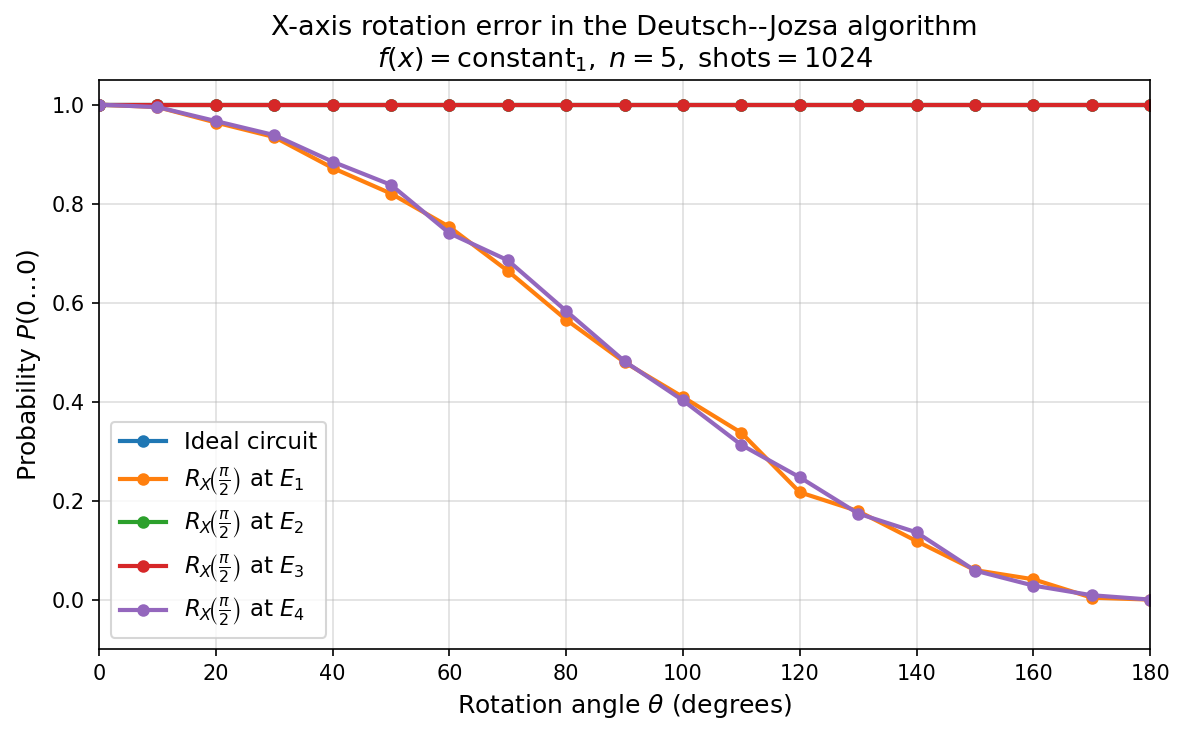

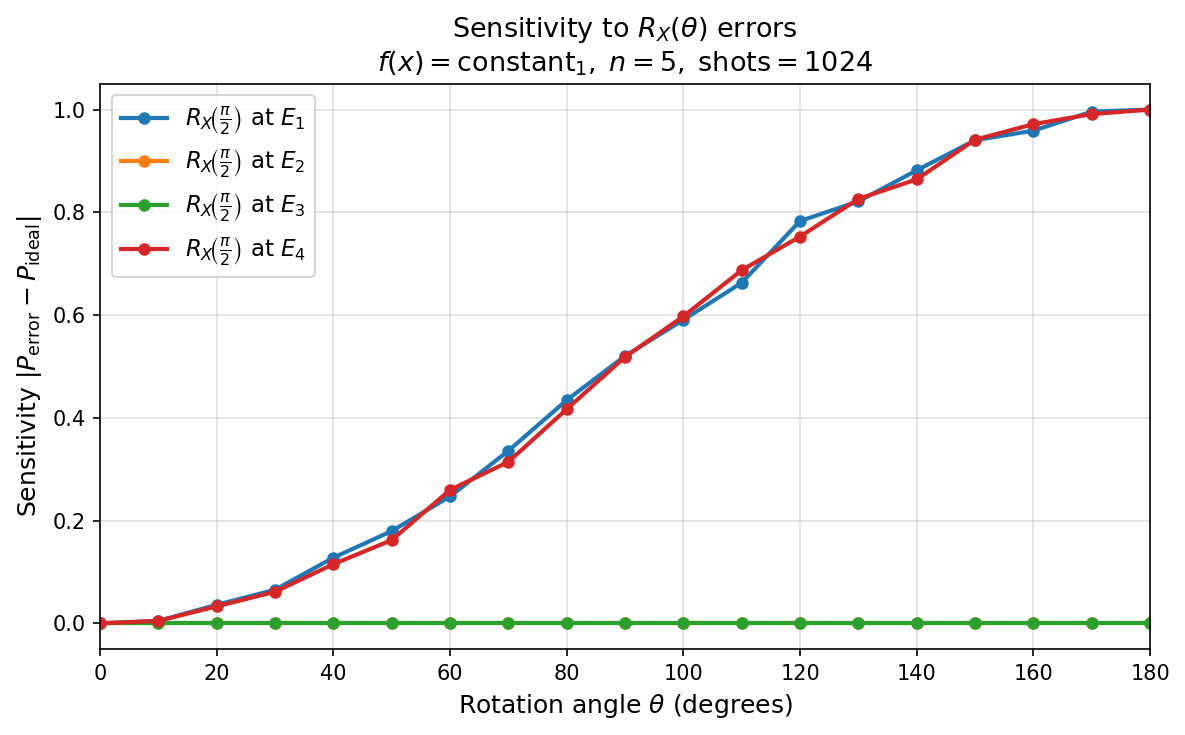

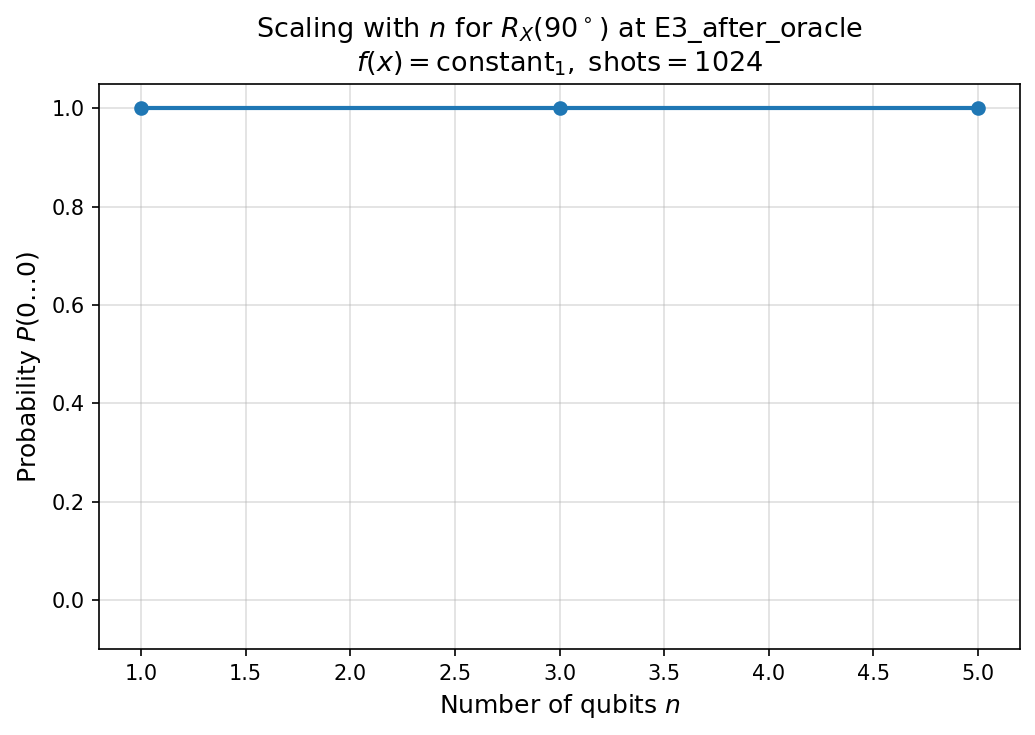

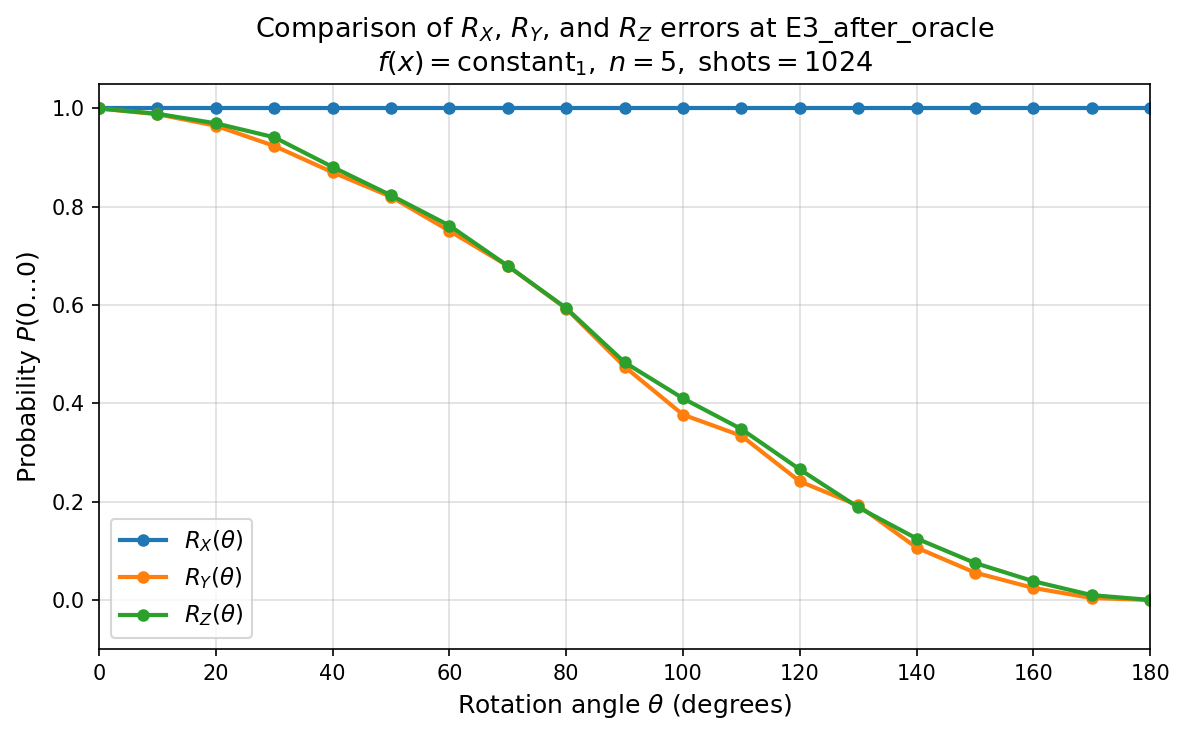

In [8]:
plot_error_positions(df, n_plot=5, axis_plot="X", function_plot="constant_1", shots=shots)

plot_sensitivity(df, n_plot=5, axis_plot="X", function_plot="constant_1", shots=shots)

plot_axis_comparison(
    df,
    n_plot=5,
    function_plot="constant_1",
    error_position="E3_after_oracle",
    shots=shots
)